In [1]:
import pandas as pd
import numpy as np
import os

DATA_PATH = os.path.join("..", "..", "data", "IMDB Dataset.csv")

df = pd.read_csv(DATA_PATH)
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

print(df.shape)
df.head()

(50000, 3)


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [1]:
import pandas as pd
import numpy as np
import os

DATA_PATH = os.path.join("..", "..", "data", "IMDB Dataset.csv")

df = pd.read_csv(DATA_PATH)
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

print(df.shape)
df.head()

(50000, 3)


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["review"]).toarray()
y = df["label"].values

print(X.shape)
print(y.shape)

(50000, 5000)
(50000,)


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["review"]).toarray()
y = df["label"].values

print(X.shape)
print(y.shape)

(50000, 5000)
(50000,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40000, 5000)
(10000, 5000)


In [6]:
model = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation="relu",
    solver="adam",
    max_iter=20,   # increase from 10 → 20
    random_state=42
)

In [8]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 0.8664
Accuracy: 86.64%


In [9]:
import os

os.makedirs(".", exist_ok=True)

with open("results.txt", "w") as f:
    f.write("Model: MLP with TF-IDF features\n")
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"Accuracy Percent: {accuracy*100:.2f}%\n")
    f.write("Input Features: TF-IDF (max_features=5000, stop_words='english')\n")
    f.write("Hidden Layer: 128 neurons\n")
    f.write("Activation: ReLU\n")
    f.write("Optimizer: Adam\n")
    f.write("Max Iterations: 20\n")

print("results.txt saved")

results.txt saved


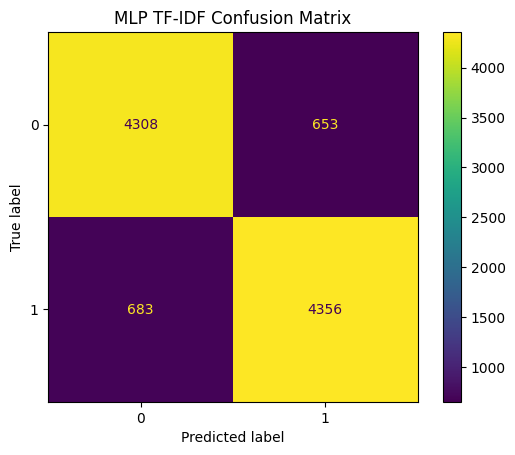

confusion_matrix.png saved


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("MLP TF-IDF Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

print("confusion_matrix.png saved")

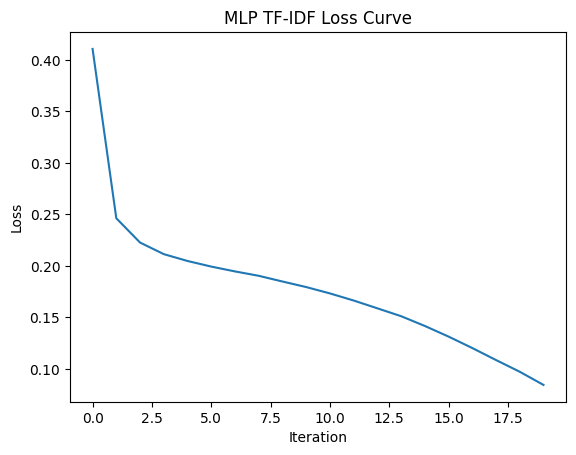

loss_curve.png saved


In [11]:
plt.figure()
plt.plot(model.loss_curve_)
plt.title("MLP TF-IDF Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.savefig("loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print("loss_curve.png saved")